# IMPORTS + LOAD DATA

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')
sns.set_style("whitegrid")

df = pd.read_csv("C:\\Users\\vaddi\\OneDrive\\Desktop\\datasets\\train_u6lujuX_CVtuZ9i (1).csv") 
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


# DATA CLEANING

In [5]:
# 1. Target
df['Loan_Status'] = df['Loan_Status'].map({'Y':1, 'N':0})

# 2. Missing values
df['Gender'].fillna(df['Gender'].mode()[0], inplace=True)
df['Married'].fillna(df['Married'].mode()[0], inplace=True)
df['Dependents'].fillna(df['Dependents'].mode()[0], inplace=True)
df['Self_Employed'].fillna(df['Self_Employed'].mode()[0], inplace=True)
df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mode()[0], inplace=True)
df['Credit_History'].fillna(df['Credit_History'].mode()[0], inplace=True)
df['LoanAmount'].fillna(df['LoanAmount'].median(), inplace=True)
df.drop('Loan_ID', axis=1, inplace=True)

df.isnull().sum()

Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

# FEATURE ENGINEERING

In [11]:

df['Dependents'] = df['Dependents'].fillna('0') 
df['Dependents'] = df['Dependents'].astype(str).str.replace('+', '') 
df['Dependents'] = pd.to_numeric(df['Dependents'], errors='coerce') 
df['Dependents'].fillna(0, inplace=True) 
df['Dependents'] = df['Dependents'].astype(int)
df['TotalIncome'] = df['ApplicantIncome'] + df['CoapplicantIncome']
df['IncomePerPerson'] = df['TotalIncome'] / (df['Dependents'] + 1) 
df['LoanAmount_Log'] = np.log(df['LoanAmount'] + 1)
df['EMI'] = df['LoanAmount'] / df['Loan_Amount_Term']
df['Income_Loan_Ratio'] = df['TotalIncome'] / (df['LoanAmount'] + 1) 

print("Features created successfully!")
df[['Dependents', 'TotalIncome', 'IncomePerPerson']].head()

Features created successfully!


,Dependents,TotalIncome,IncomePerPerson
0,0,5849.0,5849.0
1,1,6091.0,3045.5
2,0,3000.0,3000.0
3,0,4941.0,4941.0
4,0,6000.0,6000.0


# TRAIN-TEST SPLIT

In [12]:
X = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']

cat_cols = ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area', 'Credit_History']
num_cols = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term',
            'TotalIncome', 'IncomePerPerson', 'LoanAmount_Log', 'EMI', 'Income_Loan_Ratio']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (491, 16)
Test shape: (123, 16)


In [13]:
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

xgb = XGBClassifier(scale_pos_weight=1.5, random_state=42, use_label_encoder=False, eval_metric='logloss')

pipeline = Pipeline([('preprocessor', preprocessor), ('classifier', xgb)])

param_grid = {
    'classifier__n_estimators': [400],
    'classifier__max_depth': [4, 5],
    'classifier__learning_rate': [0.01, 0.05]
}

grid = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
grid.fit(X_train, y_train)

print("\nBest Params:", grid.best_params_)
print("Best CV Accuracy:", round(grid.best_score_, 4))

Fitting 5 folds for each of 4 candidates, totalling 20 fits

Best Params: {'classifier__learning_rate': 0.01, 'classifier__max_depth': 4, 'classifier__n_estimators': 400}
Best CV Accuracy: 0.7923


# LINEAR REGRESSION

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
df = pd.read_csv("C:\\Users\\vaddi\\OneDrive\\Desktop\\datasets\\train_u6lujuX_CVtuZ9i (1).csv")
print(df.head())
df.columns

    Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001002   Male      No          0      Graduate            No   
1  LP001003   Male     Yes          1      Graduate            No   
2  LP001005   Male     Yes          0      Graduate           Yes   
3  LP001006   Male     Yes          0  Not Graduate            No   
4  LP001008   Male      No          0      Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0         NaN             360.0   
1             4583             1508.0       128.0             360.0   
2             3000                0.0        66.0             360.0   
3             2583             2358.0       120.0             360.0   
4             6000                0.0       141.0             360.0   

   Credit_History Property_Area Loan_Status  
0             1.0         Urban           Y  
1             1.0         Rural           N  
2             1.0   

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='str')

Dataset
    Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001002   Male      No          0      Graduate            No   
1  LP001003   Male     Yes          1      Graduate            No   
2  LP001005   Male     Yes          0      Graduate           Yes   
3  LP001006   Male     Yes          0  Not Graduate            No   
4  LP001008   Male      No          0      Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0         NaN             360.0   
1             4583             1508.0       128.0             360.0   
2             3000                0.0        66.0             360.0   
3             2583             2358.0       120.0             360.0   
4             6000                0.0       141.0             360.0   

   Credit_History Property_Area Loan_Status  
0             1.0         Urban           Y  
1             1.0         Rural           N  
2           

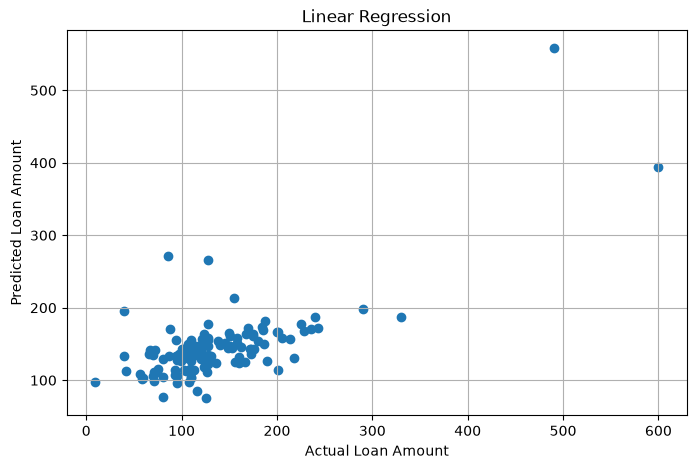

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


# Load Dataset
df = pd.read_csv(r"C:\\Users\\vaddi\\OneDrive\\Desktop\\datasets\\train_u6lujuX_CVtuZ9i (1).csv")

print("Dataset")
print(df.head())

print("\nColumns")
print(df.columns)


# Handle Missing Values

# Numerical columns
numeric_columns = [
    "ApplicantIncome",
    "CoapplicantIncome",
    "LoanAmount",
    "Loan_Amount_Term",
    "Credit_History"
]

for column in numeric_columns:
    df[column] = df[column].fillna(df[column].median())


# Categorical columns
categorical_columns = [
    "Gender",
    "Married",
    "Dependents",
    "Education",
    "Self_Employed",
    "Property_Area"
]

for column in categorical_columns:
    df[column] = df[column].fillna(df[column].mode()[0])


# Input and Output

X = df[
    [
        "Gender",
        "Married",
        "Dependents",
        "Education",
        "Self_Employed",
        "ApplicantIncome",
        "CoapplicantIncome",
        "Loan_Amount_Term",
        "Credit_History",
        "Property_Area"
    ]
]

y = df["LoanAmount"]


# Convert Categorical Columns into Numbers

X = pd.get_dummies(
    X,
    columns=[
        "Gender",
        "Married",
        "Dependents",
        "Education",
        "Self_Employed",
        "Property_Area"
    ],
    drop_first=True
)


# Split Data

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)


# Train Model

model = LinearRegression()

model.fit(X_train, y_train)


# Prediction

y_pred = model.predict(X_test)


# Results

result = pd.DataFrame({
    "Actual_LoanAmount": y_test.values,
    "Predicted_LoanAmount": y_pred
})

print("\nIntercept:")
print(model.intercept_)

print("\nCoefficient:")
print(model.coef_)

print("\nActual vs Predicted")
print(result.head(10))


# Graph

plt.figure(figsize=(8, 5))

plt.scatter(
    y_test,
    y_pred
)

plt.xlabel("Actual Loan Amount")
plt.ylabel("Predicted Loan Amount")
plt.title("Linear Regression")

plt.grid(True)

plt.show()

# Logistic regression

Dataset
    Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001002   Male      No          0      Graduate            No   
1  LP001003   Male     Yes          1      Graduate            No   
2  LP001005   Male     Yes          0      Graduate           Yes   
3  LP001006   Male     Yes          0  Not Graduate            No   
4  LP001008   Male      No          0      Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0         NaN             360.0   
1             4583             1508.0       128.0             360.0   
2             3000                0.0        66.0             360.0   
3             2583             2358.0       120.0             360.0   
4             6000                0.0       141.0             360.0   

   Credit_History Property_Area Loan_Status  
0             1.0         Urban           Y  
1             1.0         Rural           N  
2           

c:\Users\vaddi\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


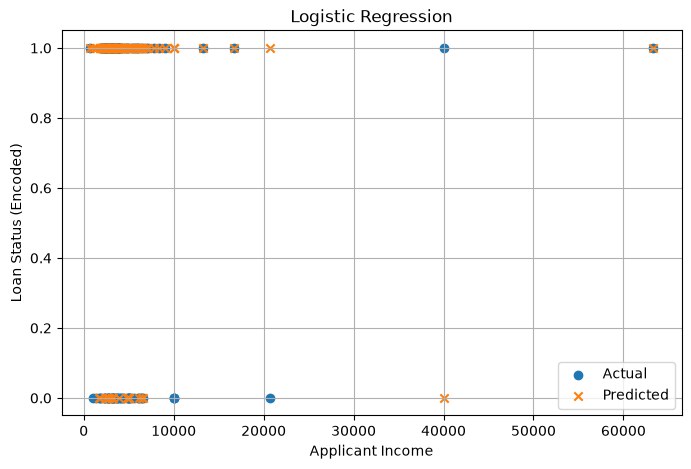

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


# Load Dataset
df = pd.read_csv(r"C:\Users\vaddi\OneDrive\Desktop\datasets\train_u6lujuX_CVtuZ9i (1).csv")

print("Dataset")
print(df.head())

print("\nColumns")
print(df.columns)


# Handle Missing Values

# Numerical columns
numeric_columns = [
    "ApplicantIncome",
    "CoapplicantIncome",
    "LoanAmount",
    "Loan_Amount_Term",
    "Credit_History"
]

for column in numeric_columns:
    df[column] = df[column].fillna(df[column].median())


# Categorical columns
categorical_columns = [
    "Gender",
    "Married",
    "Dependents",
    "Education",
    "Self_Employed",
    "Property_Area"
]

for column in categorical_columns:
    df[column] = df[column].fillna(df[column].mode()[0])


# Input and Output

X = df[
    [
        "Gender",
        "Married",
        "Dependents",
        "Education",
        "Self_Employed",
        "ApplicantIncome",
        "CoapplicantIncome",
        "LoanAmount",
        "Loan_Amount_Term",
        "Credit_History",
        "Property_Area"
    ]
]

y = df["Loan_Status"]


# Convert Categorical Input Columns into Numbers

X = pd.get_dummies(
    X,
    columns=[
        "Gender",
        "Married",
        "Dependents",
        "Education",
        "Self_Employed",
        "Property_Area"
    ],
    drop_first=True
)


# Encode Target

label_encoder = LabelEncoder()

y = label_encoder.fit_transform(y)


# Split Data

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)


# Train Model

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)


# Prediction

y_pred = model.predict(X_test)


# Results

result = pd.DataFrame({
    "Actual_Loan_Status":
        label_encoder.inverse_transform(y_test),

    "Predicted_Loan_Status":
        label_encoder.inverse_transform(y_pred)
})


print("\nIntercept:")
print(model.intercept_)

print("\nCoefficient:")
print(model.coef_)


print("\nActual vs Predicted")
print(result.head(10))


# Accuracy

print("\nAccuracy:")
print(accuracy_score(y_test, y_pred))


# Confusion Matrix

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))


# Classification Report

print("\nClassification Report")
print(classification_report(y_test, y_pred))


# Graph

plt.figure(figsize=(8, 5))

plt.scatter(
    X_test["ApplicantIncome"],
    y_test,
    label="Actual"
)

plt.scatter(
    X_test["ApplicantIncome"],
    y_pred,
    marker="x",
    label="Predicted"
)

plt.title("Logistic Regression")
plt.xlabel("Applicant Income")
plt.ylabel("Loan Status (Encoded)")

plt.legend()
plt.grid(True)

plt.show()

# ACCURACY FOR LOGISTIG REGRESSION

In [7]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Split Data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train Logistic Regression
model = LogisticRegression(
    max_iter=2000,
    C=0.1,
    solver="liblinear"
)

model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy Percentage:", accuracy * 100, "%")

# Confusion Matrix
print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

# Classification Report
print("\nClassification Report")
print(classification_report(y_test, y_pred))

Accuracy: 0.8617886178861789
Accuracy Percentage: 86.1788617886179 %

Confusion Matrix
[[22 16]
 [ 1 84]]

Classification Report
              precision    recall  f1-score   support

           0       0.96      0.58      0.72        38
           1       0.84      0.99      0.91        85

    accuracy                           0.86       123
   macro avg       0.90      0.78      0.81       123
weighted avg       0.88      0.86      0.85       123



# KNEIGHBORSCLASSIFIER

In [13]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


# Load Dataset
df = pd.read_csv(r"C:\Users\vaddi\OneDrive\Desktop\datasets\train_u6lujuX_CVtuZ9i (1).csv")

print(df.head())


# Handle Missing Values

numeric_columns = [
    "ApplicantIncome",
    "CoapplicantIncome",
    "LoanAmount",
    "Loan_Amount_Term",
    "Credit_History"
]

for column in numeric_columns:
    df[column] = df[column].fillna(df[column].median())


categorical_columns = [
    "Gender",
    "Married",
    "Dependents",
    "Education",
    "Self_Employed",
    "Property_Area"
]

for column in categorical_columns:
    df[column] = df[column].fillna(df[column].mode()[0])


# Input and Output

X = df[
    [
        "Gender",
        "Married",
        "Dependents",
        "Education",
        "Self_Employed",
        "ApplicantIncome",
        "CoapplicantIncome",
        "LoanAmount",
        "Loan_Amount_Term",
        "Credit_History",
        "Property_Area"
    ]
]

y = df["Loan_Status"]


# Convert Categorical Input Columns

X = pd.get_dummies(
    X,
    columns=[
        "Gender",
        "Married",
        "Dependents",
        "Education",
        "Self_Employed",
        "Property_Area"
    ],
    drop_first=True
)


# Encode Target

encoder = LabelEncoder()
y = encoder.fit_transform(y)


# Split Data

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


# Feature Scaling

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# KNN Model

model = KNeighborsClassifier(n_neighbors=5)

model.fit(X_train, y_train)


# Prediction

y_pred = model.predict(X_test)


# Actual vs Predicted

result = pd.DataFrame({
    "Actual": encoder.inverse_transform(y_test),
    "Predicted": encoder.inverse_transform(y_pred)
})

print("\nActual vs Predicted")
print(result.head(10))

    Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001002   Male      No          0      Graduate            No   
1  LP001003   Male     Yes          1      Graduate            No   
2  LP001005   Male     Yes          0      Graduate           Yes   
3  LP001006   Male     Yes          0  Not Graduate            No   
4  LP001008   Male      No          0      Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0         NaN             360.0   
1             4583             1508.0       128.0             360.0   
2             3000                0.0        66.0             360.0   
3             2583             2358.0       120.0             360.0   
4             6000                0.0       141.0             360.0   

   Credit_History Property_Area Loan_Status  
0             1.0         Urban           Y  
1             1.0         Rural           N  
2             1.0   

# ACCURACY FOR KNEIGHBORSCLASSIFIER

In [14]:
# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy Percentage:", accuracy * 100, "%")


# Confusion Matrix
print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))


# Classification Report
print("\nClassification Report")
print(classification_report(y_test, y_pred))

Accuracy: 0.8373983739837398
Accuracy Percentage: 83.73983739837398 %

Confusion Matrix
[[21 17]
 [ 3 82]]

Classification Report
              precision    recall  f1-score   support

           0       0.88      0.55      0.68        38
           1       0.83      0.96      0.89        85

    accuracy                           0.84       123
   macro avg       0.85      0.76      0.78       123
weighted avg       0.84      0.84      0.83       123



# DECISIONTREECLASSIFIER

In [15]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


# Load Dataset
df = pd.read_csv(r"C:\\Users\\vaddi\\OneDrive\\Desktop\\datasets\\train_u6lujuX_CVtuZ9i (1).csv")

print(df.head())


# Handle Missing Values

numeric_columns = [
    "ApplicantIncome",
    "CoapplicantIncome",
    "LoanAmount",
    "Loan_Amount_Term",
    "Credit_History"
]

for column in numeric_columns:
    df[column] = df[column].fillna(df[column].median())


categorical_columns = [
    "Gender",
    "Married",
    "Dependents",
    "Education",
    "Self_Employed",
    "Property_Area"
]

for column in categorical_columns:
    df[column] = df[column].fillna(df[column].mode()[0])


# Input and Output

X = df[
    [
        "Gender",
        "Married",
        "Dependents",
        "Education",
        "Self_Employed",
        "ApplicantIncome",
        "CoapplicantIncome",
        "LoanAmount",
        "Loan_Amount_Term",
        "Credit_History",
        "Property_Area"
    ]
]

y = df["Loan_Status"]


# Convert Categorical Input Columns

X = pd.get_dummies(
    X,
    columns=[
        "Gender",
        "Married",
        "Dependents",
        "Education",
        "Self_Employed",
        "Property_Area"
    ],
    drop_first=True
)


# Encode Target

encoder = LabelEncoder()
y = encoder.fit_transform(y)


# Split Data

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


# Decision Tree Model

model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=5,
    random_state=42
)

# Train Model
model.fit(X_train, y_train)


# Prediction
y_pred = model.predict(X_test)


# Actual vs Predicted

result = pd.DataFrame({
    "Actual": encoder.inverse_transform(y_test),
    "Predicted": encoder.inverse_transform(y_pred)
})

print("\nActual vs Predicted")
print(result.head(10))

    Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001002   Male      No          0      Graduate            No   
1  LP001003   Male     Yes          1      Graduate            No   
2  LP001005   Male     Yes          0      Graduate           Yes   
3  LP001006   Male     Yes          0  Not Graduate            No   
4  LP001008   Male      No          0      Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0         NaN             360.0   
1             4583             1508.0       128.0             360.0   
2             3000                0.0        66.0             360.0   
3             2583             2358.0       120.0             360.0   
4             6000                0.0       141.0             360.0   

   Credit_History Property_Area Loan_Status  
0             1.0         Urban           Y  
1             1.0         Rural           N  
2             1.0   

# ACCURACY FOR DECISIONTREECLASSIFIER

In [16]:
# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy Percentage:", accuracy * 100, "%")


# Confusion Matrix
print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))


# Classification Report
print("\nClassification Report")
print(classification_report(y_test, y_pred))

Accuracy: 0.8292682926829268
Accuracy Percentage: 82.92682926829268 %

Confusion Matrix
[[21 17]
 [ 4 81]]

Classification Report
              precision    recall  f1-score   support

           0       0.84      0.55      0.67        38
           1       0.83      0.95      0.89        85

    accuracy                           0.83       123
   macro avg       0.83      0.75      0.78       123
weighted avg       0.83      0.83      0.82       123

